In [22]:
# Loading datasets
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

# Define training folders
train_folders = {
    'adenocarcinoma': 'C:\\Users\\Aditi\\research\\Data\\train\\adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
    'large_cell_carcinoma': 'C:\\Users\\Aditi\\research\\Data\\train\\large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa',
    'normal': 'C:\\Users\\Aditi\\research\\Data\\train\\normal',
    'squamous_cell_carcinoma': 'C:\\Users\\Aditi\\research\\Data\\train\\squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa',
}

# Load training images and their labels
train_images = []
train_labels = []

for label, folder in train_folders.items():
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        if img_path.endswith(('.png', '.jpg', '.jpeg')):  # Add more extensions if needed
            try:
                img = Image.open(img_path).convert('RGB').resize((224, 224))  # Convert to RGB and resize
                img_array = np.array(img)  # Convert to numpy array
                train_images.append(img_array)  # Append the image
                train_labels.append(label)  # Store the corresponding label
            except Exception as e:
                print(f"Error processing image {img_path}: {e}")

# Convert lists to numpy arrays for training data
train_images_array = np.array(train_images)
train_labels_array = np.array(train_labels)

# Split the dataset into training and validation sets (80% training, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(train_images_array, train_labels_array, test_size=0.2, random_state=42)

# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)

# Convert labels to categorical
y_train_categorical = to_categorical(y_train_encoded)
y_val_categorical = to_categorical(y_val_encoded)

# Load test dataset
test_folders = {
    'adenocarcinoma': 'C:\\Users\\Aditi\\research\\Data\\test\\adenocarcinoma',
    'large_cell_carcinoma': 'C:\\Users\\Aditi\\research\\Data\\test\\large.cell.carcinoma',
    'normal': 'C:\\Users\\Aditi\\research\\Data\\test\\normal',
    'squamous_cell_carcinoma': 'C:\\Users\\Aditi\\research\\Data\\test\\squamous.cell.carcinoma',
}

# Load test images and their labels
test_images = []
test_labels = []

for label, folder in test_folders.items():
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        if img_path.endswith(('.png', '.jpg', '.jpeg')):  # Add more extensions if needed
            try:
                img = Image.open(img_path).convert('RGB').resize((224, 224))  # Convert to RGB and resize
                img_array = np.array(img)  # Convert to numpy array
                test_images.append(img_array)  # Append the image
                test_labels.append(label)  # Store the corresponding label
            except Exception as e:
                print(f"Error processing test image {img_path}: {e}")

# Convert lists to numpy arrays for test data
test_images_array = np.array(test_images)
test_labels_array = np.array(test_labels)

# Encode test labels
y_test_encoded = label_encoder.transform(test_labels_array)
y_test_categorical = to_categorical(y_test_encoded)

# Display the shape of the datasets
print("Training images shape:", X_train.shape)
print("Validation images shape:", X_val.shape)
print("Test images shape:", test_images_array.shape)
print("Training labels shape:", y_train_categorical.shape)
print("Validation labels shape:", y_val_categorical.shape)
print("Test labels shape:", y_test_categorical.shape)


Training images shape: (490, 224, 224, 3)
Validation images shape: (123, 224, 224, 3)
Test images shape: (315, 224, 224, 3)
Training labels shape: (490, 4)
Validation labels shape: (123, 4)
Test labels shape: (315, 4)


In [23]:
#model
from keras.applications import ResNet50
from keras.models import Model
from keras.layers import Flatten, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Build the ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(train_folders), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
checkpoint = ModelCheckpoint('model.keras', save_best_only=True, monitor='val_loss', mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=5)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

# Fit the model
history = model.fit(X_train, y_train_categorical,
                    validation_data=(X_val, y_val_categorical),
                    epochs=20,
                    batch_size=32,
                    callbacks=[checkpoint, early_stopping, reduce_lr])

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.4187 - loss: 6.1575 - val_accuracy: 0.8049 - val_loss: 0.9643 - learning_rate: 1.0000e-04
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.7573 - loss: 0.7872 - val_accuracy: 0.8862 - val_loss: 0.3905 - learning_rate: 1.0000e-04
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.8665 - loss: 0.3367 - val_accuracy: 0.9106 - val_loss: 0.3541 - learning_rate: 1.0000e-04
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.9312 - loss: 0.2019 - val_accuracy: 0.8699 - val_loss: 0.3309 - learning_rate: 1.0000e-04
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.9208 - loss: 0.2080 - val_accuracy: 0.9675 - val_loss: 0.2806 - learning_rate: 1.0000e-04
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.9802 - loss: 0.0813 - val_accuracy: 0.9756 - val_loss: 0.2486 - learning_rate: 1.0000e-04
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.9788 - loss:

4/4 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step
                         precision    recall  f1-score   support

         adenocarcinoma       0.98      0.95      0.96        42
   large_cell_carcinoma       0.96      0.96      0.96        26
                 normal       0.93      1.00      0.96        27
squamous_cell_carcinoma       0.96      0.93      0.95        28

               accuracy                           0.96       123
              macro avg       0.96      0.96      0.96       123
           weighted avg       0.96      0.96      0.96       123



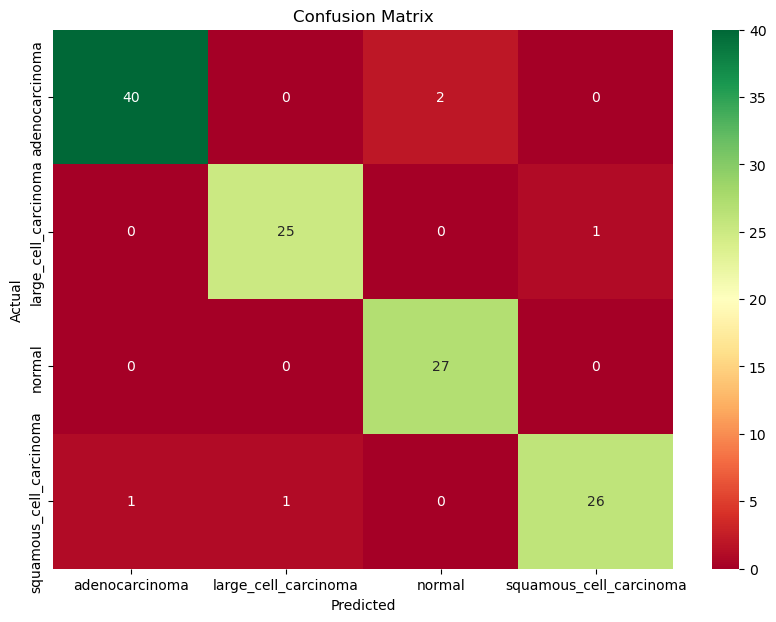

In [24]:
#Confusion matrix and classification report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Predictions on validation set
y_val_pred = model.predict(X_val)
y_val_pred_classes = np.argmax(y_val_pred, axis=1)

# Classification report
report = classification_report(y_val_encoded, y_val_pred_classes, target_names=label_encoder.classes_)
print(report)

# Confusion Matrix
conf_matrix = confusion_matrix(y_val_encoded, y_val_pred_classes)
plt.figure(figsize=(10, 7))
plt.title('Confusion Matrix')
# Change cmap to 'RdYlGn' for a red to green gradient
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='RdYlGn', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



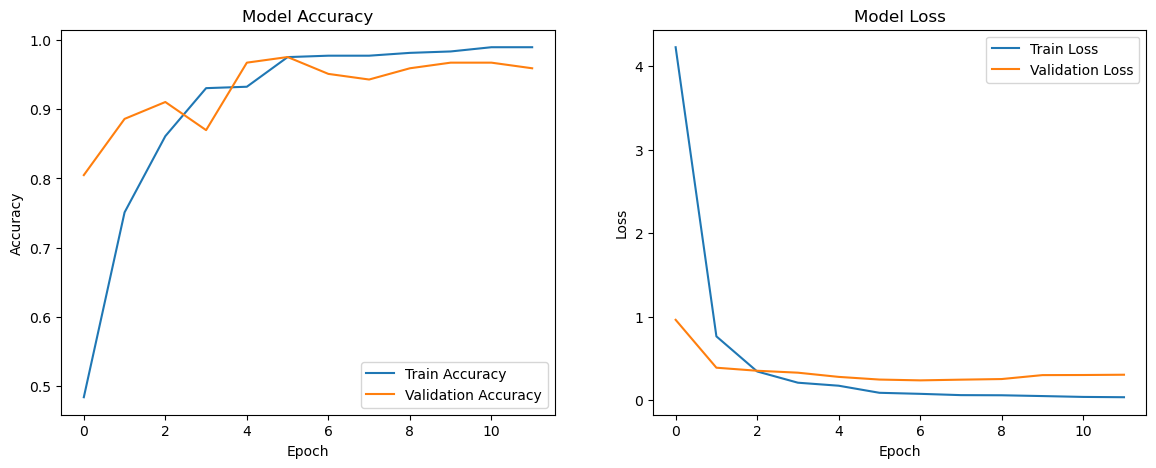

In [25]:
# Plot accuracy and loss
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()


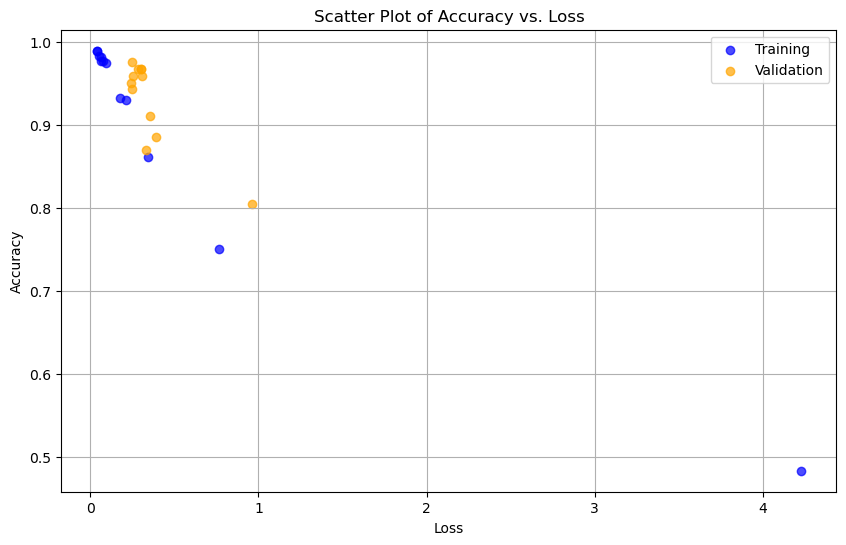

In [26]:
import matplotlib.pyplot as plt

# Assuming 'history' is the object returned by the 'model.fit()' method, containing training history
# Example: history = model.fit(...)

# Extract accuracy and loss from the training history
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Create a scatter plot for training accuracy vs. loss
plt.figure(figsize=(10, 6))
plt.scatter(loss, accuracy, label='Training', color='blue', alpha=0.7)
plt.scatter(val_loss, val_accuracy, label='Validation', color='orange', alpha=0.7)

# Add labels and title
plt.xlabel('Loss')
plt.ylabel('Accuracy')
plt.title('Scatter Plot of Accuracy vs. Loss')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


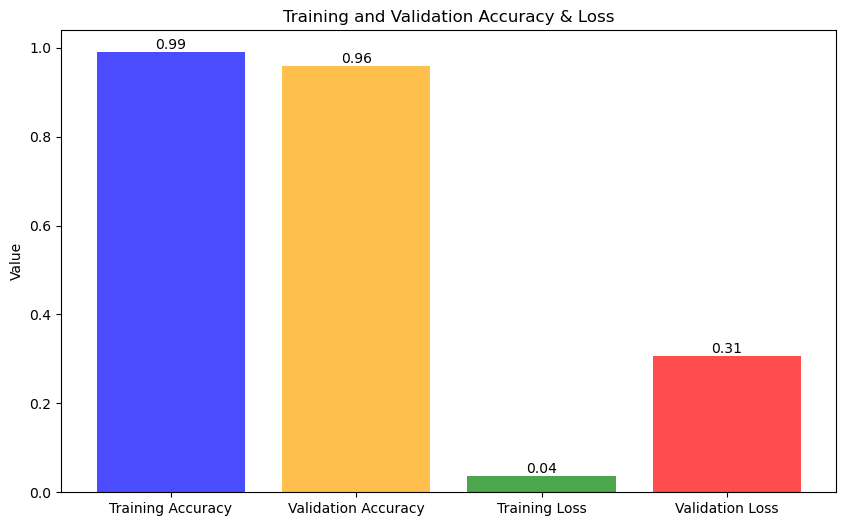

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Extract final epoch values for accuracy and loss
final_accuracy = accuracy[-1]
final_val_accuracy = val_accuracy[-1]
final_loss = loss[-1]
final_val_loss = val_loss[-1]

# Define data for bar graph
metrics = ['Training Accuracy', 'Validation Accuracy', 'Training Loss', 'Validation Loss']
values = [final_accuracy, final_val_accuracy, final_loss, final_val_loss]
colors = ['blue', 'orange', 'green', 'red']

# Create a bar graph
plt.figure(figsize=(10, 6))
bars = plt.bar(metrics, values, color=colors, alpha=0.7)

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, f'{yval:.2f}', ha='center', va='bottom')

# Add labels and title
plt.ylabel('Value')
plt.title('Training and Validation Accuracy & Loss')

# Show the plot
plt.show()


In [28]:
#testing the test dataset
import numpy as np
from PIL import Image
from keras.models import load_model
from sklearn.preprocessing import LabelEncoder

# Load the trained model
model = load_model('model.keras')  # Use the correct filename for your saved model

# Load the label encoder with the same labels used during training
label_encoder = LabelEncoder()
label_encoder.fit(['adenocarcinoma', 'large_cell_carcinoma', 'normal', 'squamous_cell_carcinoma'])

# Define messages for different outcomes
cancer_descriptions = {
    'adenocarcinoma': "Adenocarcinoma is a type of cancer that forms in mucus-secreting glands and can occur in various organs, including the lungs. It's important to consult with your doctor for further evaluation.",
    'large_cell_carcinoma': "Large cell carcinoma is a subtype of non-small cell lung cancer that tends to grow and spread quickly. Treatment options should be discussed with a healthcare professional.",
    'normal': "Great news! There are no signs of cancer detected. Keep up with regular health check-ups and maintain a healthy lifestyle.",
    'squamous_cell_carcinoma': "Squamous cell carcinoma is a type of cancer that arises from squamous cells, which are thin, flat cells found in the skin and lining of some organs. Consult your doctor for further advice."
}

def predict_ct_scan(ct_scan_path, confidence_threshold=30):  # Reduced the confidence threshold to 30%
    """
    Predict if the given CT scan image has cancer or not, and if yes, which type of cancer.
    
    Parameters:
    ct_scan_path (str): The file path to the CT scan image.
    confidence_threshold (float): The minimum confidence score (in percentage) required to consider the prediction valid.
    
    Returns:
    None
    """
    # Load and preprocess the image
    try:
        img = Image.open(ct_scan_path).convert('RGB').resize((224, 224))  # Convert to RGB and resize
        img_array = np.array(img) / 255.0  # Normalize the image
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
        
        # Predict using the model
        predictions = model.predict(img_array, verbose=0)  # Set verbose to 0 to suppress output
        predicted_class = np.argmax(predictions, axis=1)[0]
        
        # Get the predicted label
        predicted_label = label_encoder.inverse_transform([predicted_class])[0]
        
        # Get the confidence score
        confidence_score = np.max(predictions) * 100
        
        # Check if the confidence score meets the threshold
        if confidence_score < confidence_threshold:
            print(f"Predicted Label: {predicted_label} (Confidence too low: {confidence_score:.2f}%)")
            print("The model's prediction may not be reliable. Please consult with a medical professional for further evaluation.")
        else:
            # Print out the results with a detailed message
            message = cancer_descriptions[predicted_label]
            print(f"Predicted Label: {predicted_label}")
            print(f"Confidence Score: {confidence_score:.2f}%")
            print(f"Message: {message}")
        
    except Exception as e:
        print(f"Error processing image {ct_scan_path}: {e}")

# Usage
ct_scan_path = r'C:\Users\Aditi\research\Data\test\normal\7 (2).png'  
predict_ct_scan(ct_scan_path)


Predicted Label: normal
Confidence Score: 80.35%
Message: Great news! There are no signs of cancer detected. Keep up with regular health check-ups and maintain a healthy lifestyle.
